# Regime Detection using k-means and jump models

Jump models and k-means have demonstrated effectiveness in detecting market regimes. This can be seen with, e.g. the DJI. However, the literature does not provide emperical evidence for cryptocurrency. This notebook attempts to address this gap.

See also [Youssef Ahmed's notebook](https://github.com/TrilemmaFoundation/GT-MSA-S25-Trilemma-Team-14/blob/87dbe21a9d307427eee3582723bdcce378b894ee/deliverables/supplementary_technical.ipynb) for applications of $k$-means in asset accumulation 

Future extensions may include statistical jump models (which is a generalization of k-means) from [Cortese et. al. on statistical jump model](https://link.springer.com/article/10.1007/s42521-023-00085-x)

## 1. Loading data and constructing features

In [1]:
import pandas as pd 
import logging
from datetime import datetime
import requests # new import 
from io import StringIO # new import
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
import cvxportfolio as cp
from stacking_sats_pipeline import extract_all_data, extract_btc_data_to_csv

try:
    from coinmetrics.api_client import CoinMetricsClient
except ImportError:
    raise ImportError("coinmetrics.api_client module is required. Install it via pip:\n\n    pip install coinmetrics-api-client")

# Configure logging
logging.basicConfig(
    format='%(asctime)s %(levelname)-8s %(message)s',
    level=logging.INFO,
    datefmt='%Y-%m-%d %H:%M:%S'
)

# def extract_btc_data_to_csv(local_path='btc_data.csv'):
#     # Coin Metrics BTC CSV (raw GitHub URL)
#     url = "https://raw.githubusercontent.com/coinmetrics/data/master/csv/btc.csv"
#     # Download the content
#     response = requests.get(url)
#     response.raise_for_status()  # raises an error for bad responses
    
#     # Parse CSV content
#     btc_df = pd.read_csv(StringIO(response.text))

#     btc_df['time'] = pd.to_datetime(btc_df['time']).dt.normalize()
#     btc_df['time'] = btc_df['time'].dt.tz_localize('UTC')
#     btc_df.set_index('time', inplace=True)

#     btc_df.to_csv(local_path)
    
#     # Show the df
#     btc_df
    
extract_btc_data_to_csv("btc_data.csv")
#extract_btc_data_to_csv(local_path='btc_data.csv')
#btc_df = pd.read_csv('btc_data.csv', index_col = 0, parse_dates = True)    

/home/ndntam/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2026-03-13 16:44:41 INFO     Downloading BTC data from https://raw.githubusercontent.com/coinmetrics/data/master/csv/btc.csv
2026-03-13 16:44:42 INFO     Loaded CoinMetrics BTC data into memory (6279 rows)
2026-03-13 16:44:42 INFO     Saved CoinMetrics BTC data ➜ btc_data.csv


In [2]:
btc_df = pd.read_csv("btc_data.csv")
btc_df['time'] = pd.to_datetime(btc_df['time']).dt.normalize()
# btc_df['time'] = btc_df['time'].dt.tz_localize('UTC')
btc_df.set_index('time', inplace=True)

In [3]:
btc_df.columns = map(lambda x: x.replace("_coinmetrics", ""), list(btc_df.columns))
btc_df.columns

Index(['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime',
       'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD',
       'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD',
       'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD',
       'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate',
       'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur',
       'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt',
       'volume_reported_spot_usd_1d'],
      dtype='object')

In [4]:
START_DATE = '2010-07-18'
END_DATE = '2025-12-31'
def construct_features(df):
    
    #feature_df = pd.DataFrame(index = df.index)
    #df['logprice'] = df[['PriceUSD_coinmetrics']].loc[START_DATE:END_DATE].apply(np.log)
    #logprice_df.columns = ['logprice']

    #df['logvol'] = df[['volume_reported_spot_usd_1d_coinmetrics']].loc[START_DATE:END_DATE].apply(np.log)
    #logvol_df.columns = ['logvol']

    # for WINDOW in [7, 14]:
    #     df['ret'] = df['logprice'].shift(1) - df['logprice'].shift(2)
    #     df['vol'] = df['logvol'].shift(1) - df['logvol'].shift(2)
    #     df[f'ema_{WINDOW}'] = df['ret'].ewm(halflife = WINDOW).mean()
    #     df[f'vol_{WINDOW}'] = df['vol'].ewm(halflife = WINDOW).mean() 
    #     df[f'rho_{WINDOW}'] = df['ret'].ewm(halflife = WINDOW).corr(df['vol'])
       
    to_concat = dict()

    for feature in df.columns:
        past = df[feature].loc[START_DATE:END_DATE].apply(np.log).shift(1)
        if feature == 'PriceUSD':
            to_concat['logprice'] = past
        for WINDOW in [30, 90, 180, 365, 1461]:
            mean = past.rolling(window = WINDOW, min_periods =1).mean()
            if feature == 'PriceUSD':
                to_concat[f'ma{WINDOW}'] = mean
            std = past.rolling(window = WINDOW, min_periods = 1).std()
            to_concat[f'{feature}_z{WINDOW}'] = (past - mean)/std
            #print(df[f'price_z{WINDOW}'])

    # for WINDOW in [3, 20, 50, 200]:
    #     past = logprice_df['logprice'].shift(1)
    #     df[f'ma{WINDOW}'] = past.rolling(window = WINDOW, min_periods = 1).mean() 
    #     df[f'std{WINDOW}'] = past.rolling(window = WINDOW, min_periods = 1).std() 

    # print(to_concat)
    return pd.concat(to_concat, axis = 1)

In [5]:
features = construct_features(btc_df[['PriceUSD', 'CapMVRVCur']])

In [6]:
features

,logprice,ma30,PriceUSD_z30,ma90,PriceUSD_z90,ma180,PriceUSD_z180,ma365,PriceUSD_z365,ma1461,PriceUSD_z1461,CapMVRVCur_z30,CapMVRVCur_z90,CapMVRVCur_z180,CapMVRVCur_z365,CapMVRVCur_z1461
time,,,,,,,,,,,,,,,,
2010-07-18 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-19 00:00:00+00:00,-2.455270,-2.455270,NaN,-2.455270,NaN,-2.455270,NaN,-2.455270,NaN,-2.455270,NaN,NaN,NaN,NaN,NaN,NaN
2010-07-20 00:00:00+00:00,-2.515778,-2.485524,-0.707107,-2.485524,-0.707107,-2.485524,-0.707107,-2.485524,-0.707107,-2.485524,-0.707107,-0.707107,-0.707107,-0.707107,-0.707107,-0.707107
2010-07-21 00:00:00+00:00,-2.593797,-2.521615,-1.039371,-2.521615,-1.039371,-2.521615,-1.039371,-2.521615,-1.039371,-2.521615,-1.039371,-0.825742,-0.825742,-0.825742,-0.825742,-0.825742
2010-07-22 00:00:00+00:00,-2.535869,-2.525179,-0.187060,-2.525179,-0.187060,-2.525179,-0.187060,-2.525179,-0.187060,-2.525179,-0.187060,-0.834368,-0.834368,-0.834368,-0.834368,-0.834368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27 00:00:00+00:00,11.377504,11.400447,-0.925618,11.515290,-1.163007,11.581192,-1.866709,11.523257,-1.246692,10.755291,1.018001,-0.840561,-1.121539,-1.751332,-2.347410,-0.176989
2025-12-28 00:00:00+00:00,11.381625,11.399092,-0.708232,11.512555,-1.103139,11.580078,-1.802077,11.523061,-1.207926,10.755664,1.023769,-0.623419,-1.066314,-1.697887,-2.291558,-0.163823
2025-12-29 00:00:00+00:00,11.382220,11.397882,-0.637511,11.509613,-1.074133,11.579051,-1.771586,11.522840,-1.199007,10.756082,1.023692,-0.548009,-1.037670,-1.668146,-2.263006,-0.160907


## 2. Market regime classification - exploratory analysis

Improvements:
- [x] Penalty on number of transitions, in other words statistical jump models
- [ ] Try 3-state model
- [x] More data (volatility, fed rates, equity indices, sentiment, on-chain metrics, etc.). Combination of literature and self research shows current feature set gives highest Sharpe ratio
- [ ] Ignore points that are too close to decision boundaries
- [ ] Should try on-line learning (retrain with shifted window on a monthly/yearly basis?)

In [8]:
TRAIN_START = pd.Timestamp("2013-01-01").tz_localize('UTC')
TRAIN_END = pd.Timestamp("2020-12-31").tz_localize('UTC')

TEST_START = pd.Timestamp("2021-01-01").tz_localize('UTC')
TEST_END = pd.Timestamp("2024-12-31").tz_localize('UTC')

MARKET_CYCLES = {
    "2013–2016 Cycle": ("2013-01-01", "2016-12-31"),
    "2017–2020 Cycle": ("2017-01-01", "2020-12-31"),
    "2021–2024 Cycle": ("2021-01-01", "2024-12-31"),
}

# X = features[['CapMrktCurUSD_z90',\
#     'PriceUSD_z90',\
#     'CapMVRVCur_z180',\
#     'CapMrktCurUSD_z180',\
#     'PriceUSD_z180',\
#     'CapMVRVCur_z365']].bfill().dropna(axis=1, how='all')

X = features[[f'PriceUSD_z{w}' for w in [30, 90, 180, 365, 1461]]\
    + ['CapMVRVCur_z365']].dropna()

Xtrain = X[TRAIN_START:TRAIN_END]
Xtest = X[TEST_START:TEST_END]

### 2.1 $k$-means

In [ ]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt, matplotlib.dates as mdates

def fit_kmeans(X):
    kmeans = KMeans(n_clusters=3, random_state=31, n_init=10)
    kmeans.fit(X)
    return kmeans 

def visualize(labels, features, market_cycles, cluster_labels = {
        2: 'Neutral', 1: 'Bear Market',
        0: 'Bull Market' #3: 'Volatility / Transition'
    }):
    #labels_k = pd.Series(labels, index=features.index, name='cluster')
    common_idx = features.index.intersection(btc_df[['PriceUSD']].index)
    labels = labels.loc[common_idx]
    price_common = btc_df[['PriceUSD']].loc[common_idx]

    # --- Define Cycles and Loop for Plotting -----------------------------
    
    # cluster_labels = {
    #     2: 'Neutral', 1: 'Bull Market',
    #     0: 'Bear Market' #3: 'Volatility / Transition'
    # }
    
    # Loop through each defined market cycle and create a plot
    for cycle_name, (start_date, end_date) in market_cycles.items():
        cycle_mask = (price_common.index >= start_date) & (price_common.index <= end_date)
        price_cycle = price_common[cycle_mask]
        labels_cycle = labels[cycle_mask]
        
        if price_cycle.empty:
            continue
    
        fig, ax = plt.subplots(figsize=(12, 4))
        scatter = ax.scatter(price_cycle.index, price_cycle, c=labels_cycle, cmap='tab10', s=15)
        ax.set_title(f'Z-Score Regime Clusters: {cycle_name}', fontsize=14)
        ax.set_ylabel('Price (USD)')
        ax.set_xlabel('Date')
    
        colors = [scatter.cmap(scatter.norm(c)) for c in sorted(labels.unique())]
        
        # These legends are not always consistent (see below)
        legend_handles = [Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=colors[i], markersize=8,
                                 label=cluster_labels[i]) for i in sorted(cluster_labels.keys())]
        ax.legend(handles=legend_handles, title='Cluster')
    
        # Set x-axis ticks to display by year ---
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        plt.tight_layout()
        plt.show()

In [ ]:
kmeans = fit_kmeans(X)
labels = pd.Series(kmeans.predict(X), index = X.index)
visualize(labels, features = X, market_cycles = MARKET_CYCLES)

The following shows fitting k-means against the dataset from 2013-2020 gives consistent clusters for 2021-2024

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=31, n_init=10).fit(Xtrain)
train_labels = pd.Series(kmeans.predict(Xtrain), index = Xtrain.index)
test_labels = pd.Series(kmeans.predict(Xtest), index = Xtest.index)

visualize(train_labels, Xtrain, {"Training period" : (TRAIN_START,TRAIN_END)},\
    cluster_labels = {
        2: 'Bear Market', 1: 'Bull Market',
        0: 'Neutral' #3: 'Volatility / Transition'
    })
visualize(test_labels, Xtest, {"Testing period" : (TEST_START,TEST_END)}, \
     cluster_labels = {
        2: 'Bear Market', 1: 'Bull Market',
        0: 'Neutral' #3: 'Volatility / Transition'
    })

test_regimes = test_labels.map( {
        2: 'Bear Market', 1: 'Bull Market',
        0: 'Neutral' #3: 'Volatility / Transition'
    })

all_regimes = labels.map({
        2: 'Neutral', 1: 'Bear Market',
        0: 'Bull Market' #3: 'Volatility / Transition'
    })
print('Consistency rate for 2021-2024 is ', sum(test_regimes == all_regimes[test_regimes.index])/len(test_regimes))

### 2.2 Sparse jump models

This is essentially $k$-means + penalizing the number of switches

In [25]:
from jumpmodels.jump import JumpModel
from jumpmodels.sparse_jump import SparseJumpModel
from jumpmodels.plot import plot_regimes_and_cumret, plot_regimes, savefig_plt

NO_STATES = 2
jump_penalty = 20
max_feats = 5
jump = JumpModel(n_components = NO_STATES, jump_penalty = jump_penalty, cont = False).fit(Xtrain)

In [10]:
plt.rcdefaults()
def plot(labels, start_date, end_date):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
    btc_df["PriceUSD"][start_date:end_date].apply(np.log).plot(ax = ax)
    ax.set(ylabel="LogPrice")
    ax2 = ax.twinx()
    plot_regimes(labels.tz_localize(None), n_c=NO_STATES, start_date=start_date.tz_localize(None), \
                 #labels_regimes = ['Sideways', 'Bull', 'Bear'], \
                 end_date=end_date.tz_localize(None), colors_regimes=None, ax = ax2)
    ax.plot(features.loc[start_date: end_date, 'ma180'], label='ma180', linewidth=2)

/tmp/ipykernel_13916/1246404266.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(features.loc[start_date: end_date, 'ma180'], label='ma180', linewidth=2)


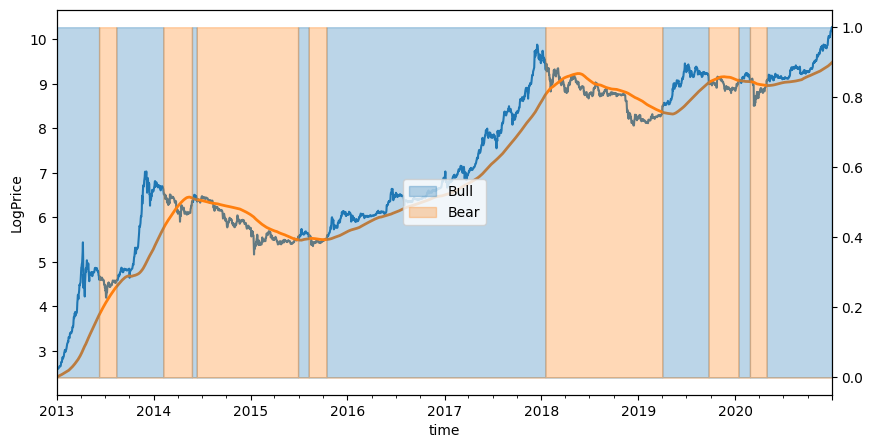

In [11]:
plot(jump.labels_, start_date = TRAIN_START, end_date = TRAIN_END)

/tmp/ipykernel_13916/1246404266.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(features.loc[start_date: end_date, 'ma180'], label='ma180', linewidth=2)


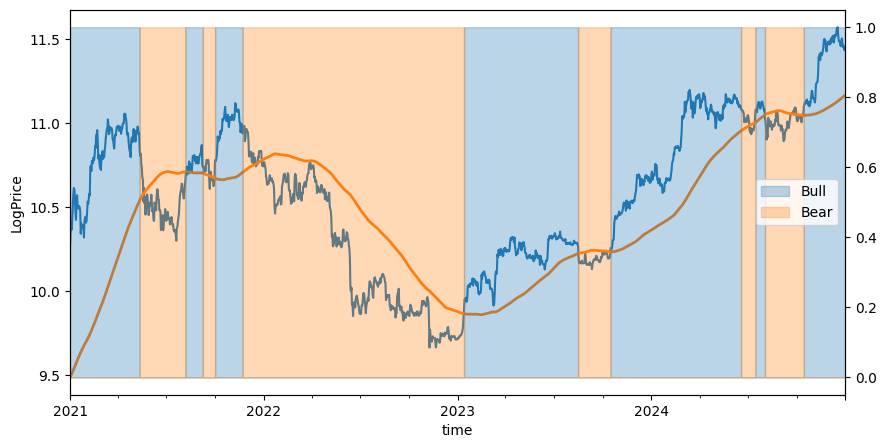

In [13]:
plot(jump.predict(Xtest), start_date = TEST_START, end_date = TEST_END)

## 3. PnL optimization/other performance metrics optimization

In [21]:
btc_returns = pd.DataFrame((btc_df["PriceUSD"].shift(-1) - btc_df["PriceUSD"])/btc_df["PriceUSD"], index = btc_df.index).rename(columns = {"PriceUSD": "BTC"})

market_data = cp.UserProvidedMarketData(
    returns=btc_returns,
    cash_key='USDOLLAR',
    #trading_calendar=btc_returns.index 
)

tcost_model = cp.TcostModel(a=10E-3, b=None)

market_sim = cp.MarketSimulator(market_data = market_data, costs = [tcost_model])

def transfer_data(labels, index):
    """Transfer (bear=1, bull=0) into (bear=0, bull=1)"""
    arr = np.where(labels == 0, 1, 0)
    cash = labels
    return pd.DataFrame({'BTC': arr, 'USDOLLAR': cash}, index=index)

def evaluate_model(predictor, X, start_time, end_time):
    labels = predictor(X)
    d = transfer_data(labels, X.index)
    policy = cp.FixedWeights(d)
    logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
    backtest_result = market_sim.run_backtest(policy, start_time=start_time, end_time=end_time)
    logging.getLogger('cvxportfolio').setLevel(logging.INFO)
    return backtest_result

def evaluate_buy_hold(X, start_time, end_time):
    policy = cp.FixedWeights(pd.DataFrame({'BTC': np.ones(len(X.index)), 'USDOLLAR': np.zeros(len(X.index))}, index=X.index))
    logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
    backtest_result = market_sim.run_backtest(policy, start_time=start_time, end_time=end_time)
    logging.getLogger('cvxportfolio').setLevel(logging.INFO)
    return backtest_result

In [ ]:
def hyperparam_tuning(hyper_params):
    M = 0
    argM = 1
    for penalty in hyper_params:
        jump =  JumpModel(n_components = NO_STATES, jump_penalty = penalty).fit(Xtrain)
        result = evaluate_model(jump, Xtrain, TRAIN_START, TRAIN_END).sharpe_ratio
        print(penalty, result)
        if result > M:
            argM = penalty
            M = result
            
    return argM, M

#hyperparam_tuning([5, 10, 20, 50, 100])
hyperparam_tuning([50, 100, 200, 500])
# hyperparam_tuning([20, 30, 50, 100])
#hyperparam_tuning([5, 10, 20, 30])

In [ ]:
result = evaluate_buy_hold(Xtest, TEST_START, TEST_END)
result

In [ ]:
jump = JumpModel(n_components = NO_STATES, jump_penalty = 100).fit(Xtrain)
result = evaluate_model(jump.predict, Xtest, TEST_START, TEST_END)
result

In [ ]:
result.plot()

## 3.1. Is optimized SJM just a simple signal (e.g. MA180 crossover)?

It turns out that the optimized SJM model agrees with a simple MA crossover signal

In [14]:
dates = jump.labels_.index
sum(jump.labels_ == (features.loc[dates, 'ma180'] > features.loc[dates, 'logprice']))/len(dates)

0.905201916495551

But how do they compare for the simple binary benchmark?

In [15]:
def ma180(X):
    return features.loc[X.index, 'ma180'] > features.loc[X.index, 'logprice']

In [16]:
ma180(jump.labels_)

time
2013-01-01 00:00:00+00:00    False
2013-01-02 00:00:00+00:00    False
2013-01-03 00:00:00+00:00    False
2013-01-04 00:00:00+00:00    False
2013-01-05 00:00:00+00:00    False
                             ...  
2020-12-27 00:00:00+00:00    False
2020-12-28 00:00:00+00:00    False
2020-12-29 00:00:00+00:00    False
2020-12-30 00:00:00+00:00    False
2020-12-31 00:00:00+00:00    False
Length: 2922, dtype: bool

In [22]:
result = evaluate_model(ma180, Xtest, TEST_START, TEST_END)
result


#################################################################
Universe size                                                   2
Initial timestamp                       2021-01-01 00:00:00+00:00
Final timestamp                         2024-12-31 00:00:00+00:00
Number of periods                                            1461
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  2.942e+06
Profit (USDOLLAR)                                       1.942e+06
                                                                 
Avg. return (annualized)                                    37.3%
Volatility (annualized)                                     45.5%
Avg. excess return (annualized)                             34.4%
Excess volatility (annualized)                              45.5%
                                                                 
Avg. growth rate (annualized)                               27.0%
Avg. exce

/home/ndntam/.local/lib/python3.12/site-packages/cvxportfolio/result.py:1014: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # pragma: no cover


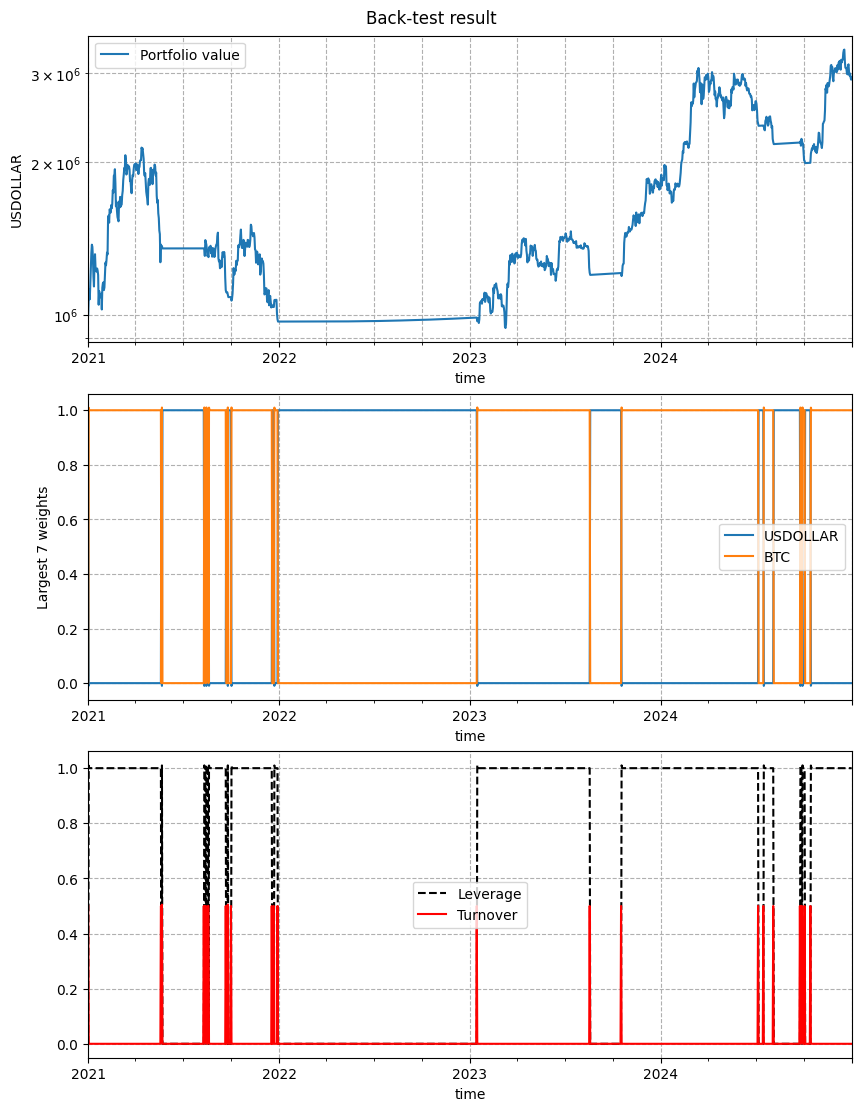

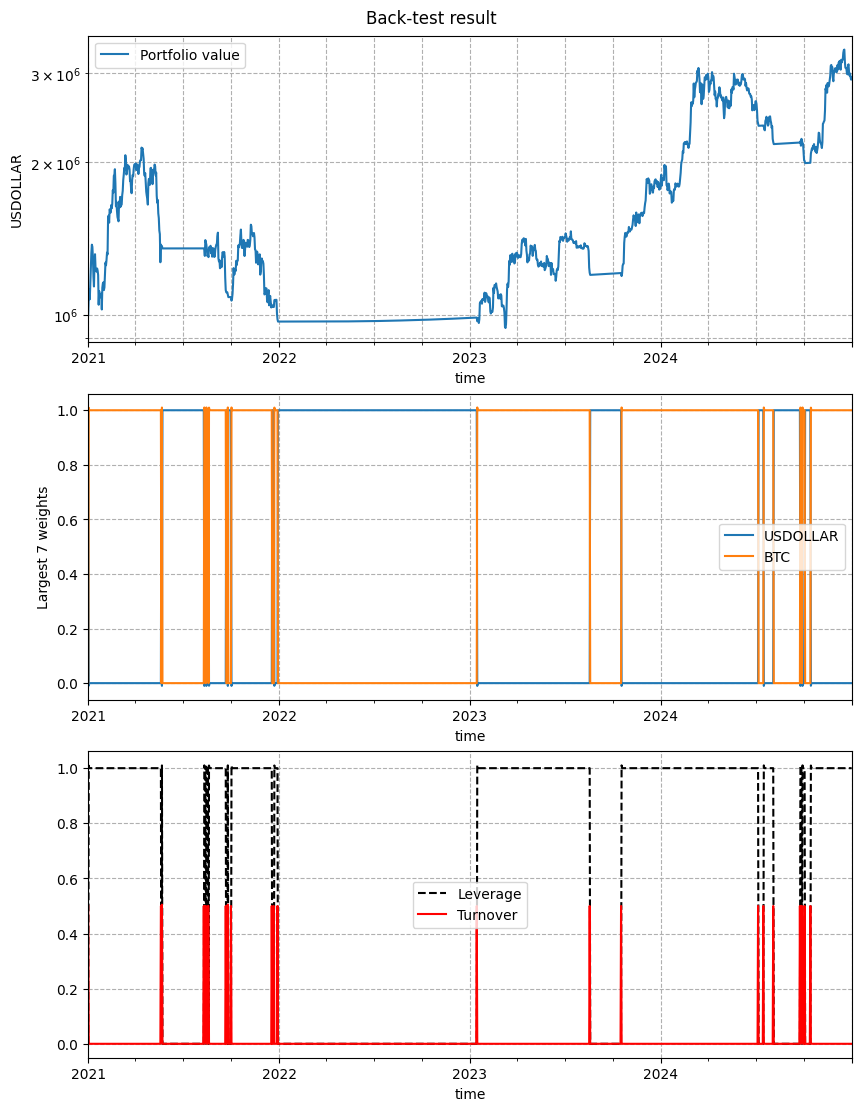

In [23]:
result.plot()

In [28]:
jump = JumpModel(n_components = NO_STATES, jump_penalty = 100).fit(Xtrain)
result = evaluate_model(jump.predict, Xtest, TEST_START, TEST_END)

In [29]:
result


#################################################################
Universe size                                                   2
Initial timestamp                       2021-01-01 00:00:00+00:00
Final timestamp                         2024-12-31 00:00:00+00:00
Number of periods                                            1461
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  8.449e+06
Profit (USDOLLAR)                                       7.449e+06
                                                                 
Avg. return (annualized)                                    62.7%
Volatility (annualized)                                     43.5%
Avg. excess return (annualized)                             59.8%
Excess volatility (annualized)                              43.5%
                                                                 
Avg. growth rate (annualized)                               53.4%
Avg. exce

/home/ndntam/.local/lib/python3.12/site-packages/cvxportfolio/result.py:1014: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # pragma: no cover


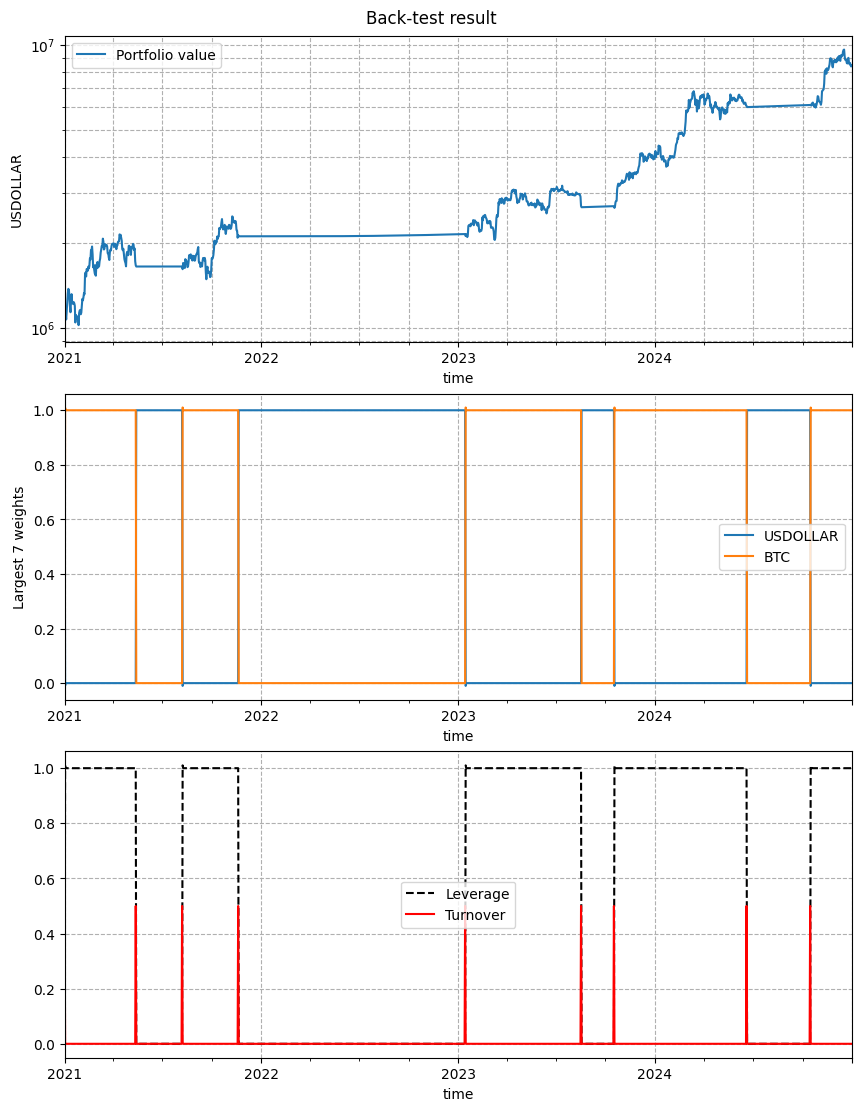

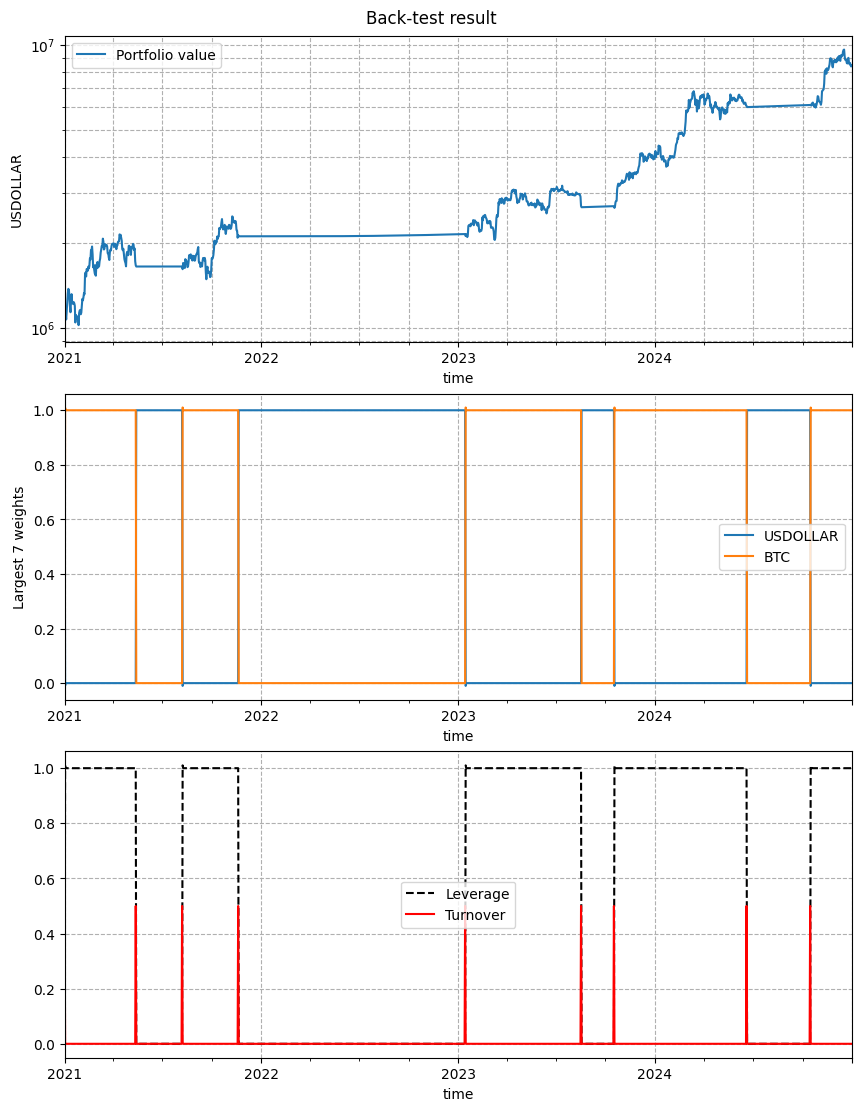

In [30]:
result.plot()

## 4. Integration into existing strategy

In [ ]:
import pandas as pd
import numpy as np

class WeightBacktester:
    def __init__(self, data, initial_capital=10E6, trade_dollars=None, weights = [1, 0],
                 commission=0.0, slippage=0.0):
        
        self.data = data.copy()
        self.initial_capital = initial_capital
        self.trade_dollars = trade_dollars
        self.trade_pct = trade_pct
        self.commission = commission
        self.slippage = slippage

    def run(self, entry_signal, exit_signal):

        df = self.data.copy()
        df['entry'] = entry_signal.shift(1)
        df['exit'] = exit_signal.shift(1)

        cash = self.initial_capital
        shares = 0
        position_value = 0

        equity_curve = []
        trades = []
        total_equity = self.initial_capital

        entry_price = None

        for i in range(len(df) - 1):  # skip last row for shift safety

            price = df['Close'].iloc[i]

            # -----------------------
            # EXIT
            # -----------------------
            if shares > 0 and df['exit'].iloc[i]:
                exec_price = price * (1 - self.slippage)

                proceeds = shares * exec_price
                cost = proceeds * self.commission

                cash += proceeds - cost

                trades.append({
                    'date': df.index[i],
                    'type': 'EXIT',
                    'price': exec_price,
                    'shares': shares,
                    'cash': cash,
                })

                shares = 0
                entry_price = None

            # -----------------------
            # ENTRY
            # -----------------------
            if shares == 0 and df['entry'].iloc[i]:
                exec_price = price * (1 + self.slippage)

                if self.trade_pct is not None:
                    self.trade_dollars = self.trade_pct * total_equity
                
                shares = self.trade_dollars / exec_price
                cost = self.trade_dollars * self.commission

                cash -= self.trade_dollars + cost
                entry_price = exec_price

                trades.append({
                    'date': df.index[i],
                    'type': 'ENTRY',
                    'price': exec_price,
                    'shares': shares,
                    'cash': cash
                })

            # -----------------------
            # EQUITY UPDATE
            # -----------------------
            position_value = shares * price
            total_equity = cash + position_value

            equity_curve.append(total_equity)

        df_result = df.iloc[:-1].copy()
        df_result['equity'] = equity_curve


Improvements:
- [ ] Try long-short instead, incorporating holding costs, etc.

In [ ]:
# weights for cvxportfolio backtesting
def mean_reversion(df, upper, lower):
    weights = pd.DataFrame(index=df.index)
    weights['BTC'] = np.nan

    weights.loc[df["ma3"] < df["ma20"]  - lower * df["std20"], 'BTC'] = 1
    weights.loc[df["ma3"] >=  df["ma20"] + upper * df["std20"], 'BTC'] = 0

    weights['BTC'] = weights['BTC'].ffill()
    weights['BTC'] = weights['BTC'].fillna(0)

    weights['USDOLLAR'] = 1 - weights['BTC']
    # for i in df.index:
    #     if df.loc[i, "ma3"] < df.loc[i, "ma20"] - 2 * df.loc[i, "std20"]:
    #         weights.loc[i, 'BTC'] = 1
    #         weights.loc[i, 'USDOLLAR'] = 0
    #         #print("underpriced")
    #     elif df.loc[i, "ma3"] > df.loc[i, "ma20"] + 2 * df.loc[i, "std20"]:
    #         weights.loc[i, 'BTC'] = 0
    #         weights.loc[i, 'USDOLLAR'] = 1
    #         #print("overpriced")
    #     else:
    #         if i > df.index[0]:
    #             weights.loc[i, 'BTC'] = weights.loc[i - pd.Timedelta(days = 1), 'BTC']
    #             weights.loc[i, 'USDOLLAR'] = weights.loc[i - pd.Timedelta(days = 1), 'USDOLLAR']
        #print(weights.loc[i, :])    
    return weights

In [ ]:
def hyperparam_tuning(hyper_params):
    M = 0
    argM = hyper_params[0]
    for upper, lower in hyper_params:
        weights = mean_reversion(features.loc[TRAIN_START:TRAIN_END, ["ma3", "ma20", "std20"]], upper, lower)
        policy = cp.FixedWeights(weights)
        logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
        backtest_result = market_sim.run_backtest(policy, start_time=TRAIN_START, end_time=TRAIN_END)
        logging.getLogger('cvxportfolio').setLevel(logging.INFO)
        result = backtest_result.sharpe_ratio
        print((upper, lower), result)
        if result > M:
            argM = (upper, lower)
            M = result
            
    return argM, M

#hyperparam_tuning([1, 5, 10, 20, 50, 100])
#hyperparam_tuning([(1, 0), (0, 1), (0.5, 0.5), (1, 1), (1.25, 1.25)])
#hyperparam_tuning([(0.5, 1), (1, 0.5), (1.25, 1.25), (1.5, 1.5)])
#hyperparam_tuning([(1.5, 1.5), (2.0, 2.0), (1.5, 2.0), (2.0, 1.5)])
hyperparam_tuning([(2.0, 1.5), (2.0, 1.75), (2.0, 1.25), (2.0, 1.0)])

In [ ]:
weights = mean_reversion(features.loc[TEST_START:TEST_END, ["ma3", "ma20", "std20"]], 2.0, 1.75)

In [ ]:
policy = cp.FixedWeights(weights)
logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
backtest_result = market_sim.run_backtest(policy, start_time=TEST_START, end_time=TEST_END)
logging.getLogger('cvxportfolio').setLevel(logging.INFO)

In [ ]:
backtest_result

In [ ]:
jump = JumpModel(2, jump_penalty = 100, cont=False, mode_loss=False, random_state=42).fit(Xtrain)
regime_train_labels = jump.predict(Xtrain)
regime_test_labels = jump.predict(Xtest)

def regime_mean_reversion(df, labels, upper, lower):
    weights = pd.DataFrame(index=df.index)
    weights['BTC'] = np.nan

    weights.loc[(df["ma3"] < df["ma20"] - lower * df["std20"]) & (labels == 0), 'BTC'] = 1
    weights.loc[(df["ma3"] > df["ma20"] + upper * df["std20"]) & (labels == 0), 'BTC'] = 0

    weights['BTC'] = weights['BTC'].ffill()
    weights['BTC'] = weights['BTC'].fillna(0)

    weights['USDOLLAR'] = 1 - weights['BTC']
    # for i in df.index:
    #     if df.loc[i, "ma3"] < df.loc[i, "ma20"] - 2 * df.loc[i, "std20"]:
    #         weights.loc[i, 'BTC'] = 1
    #         weights.loc[i, 'USDOLLAR'] = 0
    #         #print("underpriced")
    #     elif df.loc[i, "ma3"] > df.loc[i, "ma20"] + 2 * df.loc[i, "std20"]:
    #         weights.loc[i, 'BTC'] = 0
    #         weights.loc[i, 'USDOLLAR'] = 1
    #         #print("overpriced")
    #     else:
    #         if i > df.index[0]:
    #             weights.loc[i, 'BTC'] = weights.loc[i - pd.Timedelta(days = 1), 'BTC']
    #             weights.loc[i, 'USDOLLAR'] = weights.loc[i - pd.Timedelta(days = 1), 'USDOLLAR']
        #print(weights.loc[i, :])    
    return weights

In [ ]:
def hyperparam_tuning(hyper_params):
    M = 0
    argM = hyper_params[0]
    for upper, lower in hyper_params:
        weights = regime_mean_reversion(features.loc[TRAIN_START:TRAIN_END, ["ma3", "ma20", "std20"]], regime_train_labels, upper, lower)
        policy = cp.FixedWeights(weights)
        logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
        backtest_result = market_sim.run_backtest(policy, start_time=TRAIN_START, end_time=TRAIN_END)
        logging.getLogger('cvxportfolio').setLevel(logging.INFO)
        result = backtest_result.sharpe_ratio
        print((upper, lower), result)
        if result > M:
            argM = (upper, lower)
            M = result
            
    return argM, M

In [ ]:
#hyperparam_tuning([(1, 0), (0, 1), (0.5, 0.5), (1, 1), (1.25, 1.25)])
#hyperparam_tuning([(1, 0), (1, 0.5), (1.25, 1.25), (1.5, 1.5), (2.0, 2.0)])
#hyperparam_tuning([(2.0, 2.0), (2.0, 1.75), (2.0, 0)])
#hyperparam_tuning([(2.0, 2.0), (2.0, 1), (2.0, 0)])
hyperparam_tuning([(2, 0), (1.75, 0), (1.5, 0), (1.25, 0)])

In [ ]:
weights = regime_mean_reversion(features.loc[TEST_START:TEST_END, ["ma3", "ma20", "std20"]], regime_test_labels, 2, 0)

In [ ]:
policy = cp.FixedWeights(weights)
logging.getLogger('cvxportfolio').setLevel(logging.ERROR)
backtest_result = market_sim.run_backtest(policy, start_time=TEST_START, end_time=TEST_END)
logging.getLogger('cvxportfolio').setLevel(logging.INFO)
backtest_result